# EE 585 Probabilistic Robotics

## Homework #2 (Individual Work)

### Given: Nov 04,2025 (Tue), Due: Nov 19,2025 (Wed) 23:59

General Information About the Homeworks:

Homeworks are to be prepared in Electronic Form composed of an
Adobe
pdf
format
homework
document
“Surname_HW1.pdf”
and
associated Matlab/Python files (if applicable) having name
specified in the homework. All should be packed in a zip file
having Surname_hw1.zip and uploaded to the appropriate assignment
entry in OdtuClass. If required, the document should give all
derivations, mathematical solutions, Matlab/Phython figures and
comments on your results. All equations must be typeset in a
legible and understandable form. The organization and neatness of
the homework is an important consideration in grading.
The electronic document should be accompanied by the necessary
Matlab m-files (only data files and plotting functions if Python
is used) that can be run from a clean Matlab session (no previously
defined variables) and provide all the necessary output. The
programs should indicate on the command window what they are in
the process of doing.

### Q1: Consider Chapter 1, Part of Ex. 2 from your textbook:

Suppose we live at a place where days are either sunny, cloudy, or rainy.
The weather transition function is a Markov chain with the following tran-
sition table:

|    tomorrow will be ->    | sunny | cloudy | rainy |
|--------|-------|--------|-------|
| today it's ... sunny  | 0.8   | 0.2    | 0.0   |
| cloudy | 0.4   | 0.4    | 0.2   |
| rainy  | 0.2   | 0.6    | 0.2   |

* (a) Suppose Day 1 is a sunny day. What is the probability of the following
sequence of days: Day2 = cloudy, Day3 = cloudy, Day4 = rainy?
* (b) Write a simulator that can randomly generate sequences of “weathers”
from this state transition function.

(Note: Use Matlab to write this simulator. The m-file should have name
generate_weather.m)
in our case we will generate a python script and need to name it generate_weather.py

### A1.1:

P(sequence) = 0.2 * 0.4 * 0.2 = 0.016

### A1.2:

In [2]:
import numpy as np
from collections import Counter

STATES = ["sunny", "cloudy", "rainy"]
IDX = {s: i for i, s in enumerate(STATES)}

# Transition matrix P[row = today, col = tomorrow]
P = np.array([
    [0.8, 0.2, 0.0],  # today = sunny
    [0.4, 0.4, 0.2],  # today = cloudy
    [0.2, 0.6, 0.2],  # today = rainy
], dtype=float)

def sequence_probability(start_state: str, seq_states: list[str]) -> float:
    """Exact probability of a specific sequence given the start state."""
    cur = IDX[start_state]
    prob = 1.0
    for s in seq_states:
        nxt = IDX[s]
        prob *= P[cur, nxt]
        cur = nxt
    return prob

def simulate_weather(initial_state: str, length: int, rng: np.random.Generator) -> list[str]:
    """Simulate a single weather sequence (includes the initial day)."""
    seq = [initial_state]
    cur = IDX[initial_state]
    for _ in range(length):
        cur = rng.choice(3, p=P[cur])
        seq.append(STATES[cur])
    return seq

def estimate_sequence_probability_mc(start_state: str, target_seq: list[str], trials: int = 200_000, seed: int = 0) -> float:
    """Monte Carlo estimate of the probability of target_seq following start_state."""
    rng = np.random.default_rng(seed)
    match = 0
    for _ in range(trials):
        cur = IDX[start_state]
        ok = True
        for s in target_seq:
            cur = rng.choice(3, p=P[cur])
            if STATES[cur] != s:
                ok = False
                break
        if ok:
            match += 1
    return match / trials

def estimate_stationary_distribution(steps: int = 2_000_000, burn_in: int = 10_000, seed: int = 0) -> dict[str, float]:
    """Estimate the stationary distribution by long-run simulation."""
    rng = np.random.default_rng(seed)
    cur = IDX["sunny"]
    counts = np.zeros(3, dtype=np.int64)
    for t in range(steps + burn_in):
        cur = rng.choice(3, p=P[cur])
        if t >= burn_in:
            counts[cur] += 1
    freqs = counts / counts.sum()
    return {STATES[i]: float(freqs[i]) for i in range(3)}

if __name__ == "__main__":
    # (a) Exact probability
    exact = sequence_probability("sunny", ["cloudy", "cloudy", "rainy"])
    print(f"Exact P(S->C->C->R) = {exact:.6f}")

    # MC verification
    mc = estimate_sequence_probability_mc("sunny", ["cloudy", "cloudy", "rainy"])
    print(f"MC   P(S->C->C->R) ≈ {mc:.6f}")

    # Example simulation and histogram
    rng = np.random.default_rng(42)
    seq = simulate_weather("sunny", length=10_000, rng=rng)
    counts = Counter(seq)
    total = sum(counts.values())
    print("Empirical frequencies over simulated days:")
    for s in STATES:
        print(f"  {s:6s}: {counts[s] / total:.4f}")

    # Stationary distribution estimate
    pi_hat = estimate_stationary_distribution()
    print("Estimated stationary distribution:")
    for s in STATES:
        print(f"  {s:6s}: {pi_hat[s]:.4f}")

Exact P(S->C->C->R) = 0.016000
MC   P(S->C->C->R) ≈ 0.015965
Empirical frequencies over simulated days:
  sunny : 0.6445
  cloudy: 0.2875
  rainy : 0.0680
Estimated stationary distribution:
  sunny : 0.6422
  cloudy: 0.2863
  rainy : 0.0715


### Q2: Generate and Display Samples from Velocity Motion Model

Consider the velocity motion model discussed in Page 34 of your
lecture slides (Motion Models).
* (a) Implement this “ideal” forward model as a Matlab m-
function motion_model_ideal()(in our case Python) from the current state to
the next state within a time duration Δt (also an argument
to the function). For an example v and w, illustrate the
“simulated motion” by using a small Δt and multiple calls
to this function. This will generate a sequence of poses
for the robot which you will plot. You may use the quiver()
plot function of Matlab to plot the position and
orientation (x,y,θ). Hint: You may attempt to imitate a
motion used for the examples of Page 39 of your lecture
slides.
* (b) Implement the noisy version of the model as a Matlab m-
function motion_model_noisy()(in our case Python) which have Δt and three
noise variances as parameters. Select a suitable Δt (maybe
larger than in part (a)) and this time starting from the
same initial state, “sample” this model N times for
different noise variances to imitate the three figures at
the bottom of Page 39 of your slides. Note: You may omit
robot body circles and only initial pose and final poses.
Note: Try to use quiver() plot to show orientation as well
as position. If that is too cluttered, reduce N or plot
positions only.
* (c) Give the three noise variance values for the three plots
that you have generated in approximation of Page 39 of
your lecture slides. Discuss the relation between the
distribution of the samples and the set of variances that
was used to generate them.

### A2.1:

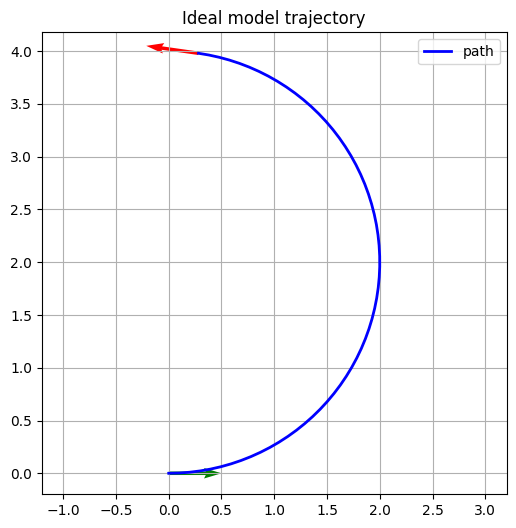

In [3]:
# Q2(a) — Ideal velocity motion model and a simple trajectory demo
import numpy as np
import matplotlib.pyplot as plt

def wrap_angle(theta: float) -> float:
    return (theta + np.pi) % (2*np.pi) - np.pi

def motion_model_ideal(pose, v: float, w: float, dt: float, eps: float = 1e-9):
    x, y, th = pose
    if abs(w) < eps:
        x_p = x + v * dt * np.cos(th)
        y_p = y + v * dt * np.sin(th)
        th_p = th  # straight motion, no rotation
    else:
        v_over_w = v / w
        th_dt = th + w * dt
        x_p = x - v_over_w * np.sin(th) + v_over_w * np.sin(th_dt)
        y_p = y + v_over_w * np.cos(th) - v_over_w * np.cos(th_dt)
        th_p = th_dt
    return (x_p, y_p, wrap_angle(th_p))

# Demo trajectory
pose = (0.0, 0.0, 0.0)
v, w, dt = 1.0, 0.5, 0.1
traj = [pose]
for _ in range(60):
    pose = motion_model_ideal(pose, v, w, dt)
    traj.append(pose)

xs = [p[0] for p in traj]
ys = [p[1] for p in traj]
ths = [p[2] for p in traj]

plt.figure(figsize=(6,6))
plt.plot(xs, ys, '-b', lw=2, label='path')
# quiver initial and final
scale = 0.5
plt.quiver([xs[0], xs[-1]], [ys[0], ys[-1]],
           [np.cos(ths[0])*scale, np.cos(ths[-1])*scale],
           [np.sin(ths[0])*scale, np.sin(ths[-1])*scale],
           angles='xy', scale_units='xy', scale=1, color=['g','r'])
plt.axis('equal'); plt.grid(True); plt.legend(); plt.title('Ideal model trajectory')
plt.show()

### A2.2:

<Figure size 640x480 with 0 Axes>

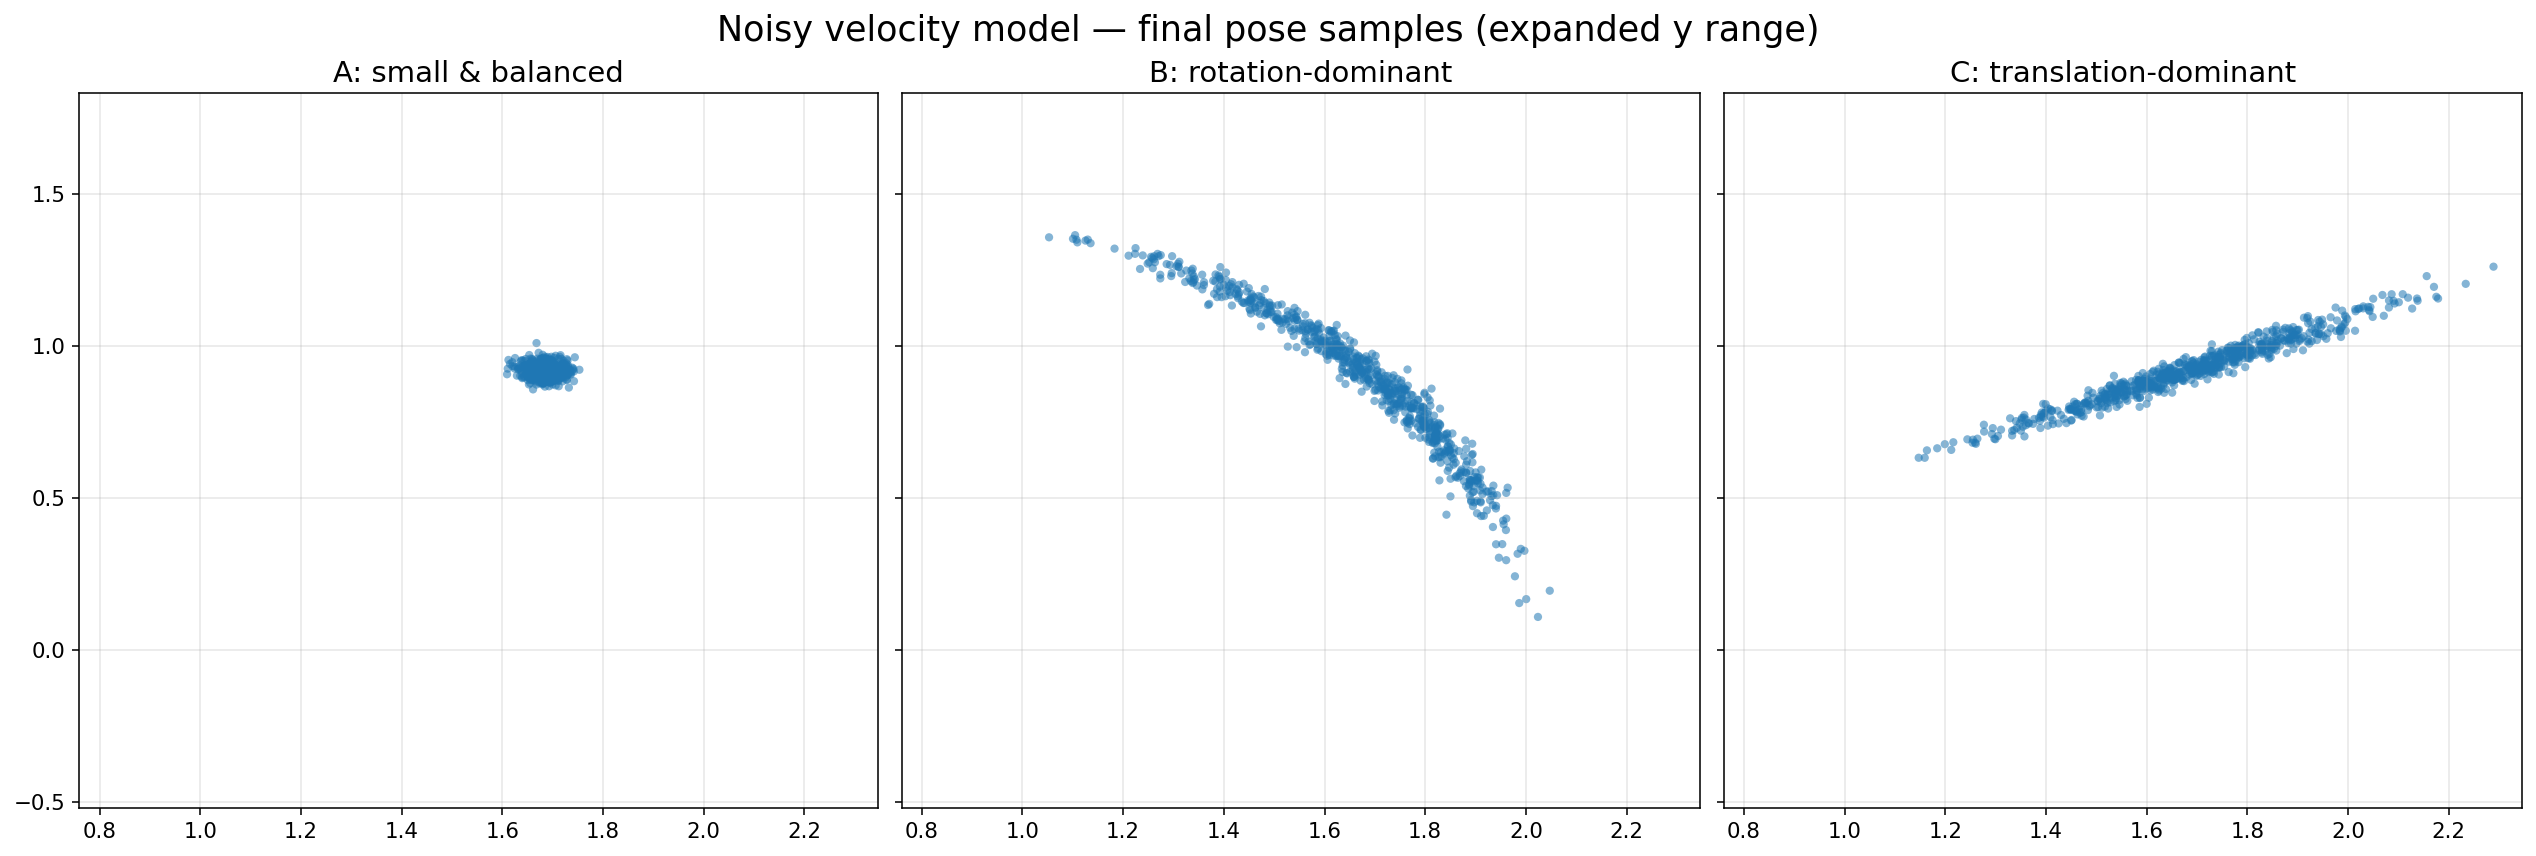

In [20]:
# Q2(b) — Noisy velocity motion model (canonical 6-alpha version) and sampling
rng = np.random.default_rng(585)

def _sample_var(var: float, rng) -> float:
    return 0.0 if var <= 0.0 else rng.normal(0.0, np.sqrt(var))

def motion_model_noisy(pose, v: float, w: float, dt: float, alphas, rng, eps: float = 1e-9):
    a1,a2,a3,a4,a5,a6 = alphas
    v_hat = v + _sample_var(a1*v*v + a2*w*w, rng)
    w_hat = w + _sample_var(a3*v*v + a4*w*w, rng)
    gamma_hat = _sample_var(a5*v*v + a6*w*w, rng)

    x, y, th = pose
    if abs(w_hat) < eps:
        x_p = x + v_hat * dt * np.cos(th)
        y_p = y + v_hat * dt * np.sin(th)
    else:
        v_over_w = v_hat / w_hat
        th_dt = th + w_hat * dt
        x_p = x - v_over_w * np.sin(th) + v_over_w * np.sin(th_dt)
        y_p = y + v_over_w * np.cos(th) - v_over_w * np.cos(th_dt)

    th_p = (th + w_hat * dt + gamma_hat * dt + np.pi) % (2*np.pi) - np.pi
    return (x_p, y_p, th_p)

def sample_final_poses(initial_pose, v, w, dt, alphas, N: int, rng):
    return np.array([motion_model_noisy(initial_pose, v, w, dt, alphas, rng) for _ in range(N)])

initial_pose = (0.0, 0.0, 0.0)
v, w, dt = 1.0, 0.5, 2
N = 700

alpha_sets = {
    "A: small & balanced": (1e-4, 1e-4, 1e-4, 1e-4, 1e-4, 1e-4),
    "B: rotation-dominant": (1e-4, 1e-4, 2e-2, 2e-2, 2e-2, 2e-2),
    "C: translation-dominant": (1e-2, 1e-2, 1e-4, 1e-4, 1e-4, 1e-4),
}

# Pre-sample to compute global bounds
all_poses = []
for alphas in alpha_sets.values():
    poses_tmp = sample_final_poses(initial_pose, v, w, dt, alphas, N, rng)
    all_poses.append(poses_tmp)
all_poses = np.vstack(all_poses)

xmin, xmax = all_poses[:,0].min(), all_poses[:,0].max()
ymin, ymax = all_poses[:,1].min(), all_poses[:,1].max()
pad_x = 0.1 * (xmax - xmin if xmax > xmin else 1.0)
pad_y = 0.25 * (ymax - ymin if ymax > ymin else 1.0)  # extra y padding

plt.figure()
fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True, dpi=140, constrained_layout=True)
for ax, (name, alphas) in zip(axs, alpha_sets.items()):
    poses = sample_final_poses(initial_pose, v, w, dt, alphas, N, rng)
    ax.scatter(poses[:,0], poses[:,1], s=18, alpha=0.55, edgecolors='none')
    #scale = 0.7
    ax.quiver([initial_pose[0]], [initial_pose[1]],
              [np.cos(initial_pose[2])*scale], [np.sin(initial_pose[2])*scale],
              angles='xy', scale_units='xy', scale=1, color='k')
    ax.set_title(name, fontsize=15)
    ax.grid(True, alpha=0.3)
    #ax.set_aspect('equal', 'box')
    ax.tick_params(labelsize=11)

# Apply expanded limits
for ax in axs:
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)

fig.suptitle('Noisy velocity model — final pose samples (expanded y range)', fontsize=18)
plt.show()

### A2.3:

In [9]:
# Q2(c) — Report the three (sets of) noise parameters you used
alpha_sets

{'A: small & balanced': (0.0001, 0.0001, 0.0001, 0.0001, 0.0001, 0.0001),
 'B: rotation-dominant': (0.0001, 0.0001, 0.02, 0.02, 0.02, 0.02),
 'C: translation-dominant': (0.01, 0.01, 0.0001, 0.0001, 0.0001, 0.0001)}

### Q3: Solve Chapter 5, Question 1 From your Textbook.

The question is about including the Dynamics of the robot in
the motion model for a 1D robot.

All robot models in this chapter were kinematic. In this exercise, you
will consider a robot with dynamics. Consider a robot that lives in a 1-D
coordinate system. Its location will be denoted by x, its velocity by ẋ,
and its acceleration by ẍ. Suppose we can only control the acceleration
ẍ. Develop a mathematical motion model that computes the posterior
over the pose x' and the velocity ẋ' from an initial pose x and velocity ẋ,
assuming that the acceleration ẍ is the sum of a commanded acceleration
and a zero-mean Gaussian noise term with variance σ 2 (and assume that
the actual acceleration remains constant in the simulation interval Δt).
Are x' and ẋ' correlated in the posterior? Explain why/why not.

1. State: Our state vector is $x_t = \begin{pmatrix} x_t \\ \dot{x}_t \end{pmatrix}$.
2. Control: Our control is :  $u_t = \ddot{x}_t$.
3. Kinematics: Equations for constant acceleration over an interval  $\Delta t$:
    * $x_t = x_{t-1} + \dot{x}_{t-1}\Delta t + \frac{1}{2}\ddot{x}_t(\Delta t)^2$

    * $\dot{x}_t = \dot{x}_{t-1} + \ddot{x}_t\Delta t$
4. Linear Model: $x_t = A_t x_{t-1} + B_t u_t + \epsilon_t$ (from the textbook Eq. 3.2, page 41.)
    * $A_t = \begin{pmatrix} 1 & \Delta t \\ 0 & 1 \end{pmatrix}$

    * $B_t = \begin{pmatrix} \frac{1}{2}(\Delta t)^2 \\ \Delta t \end{pmatrix}$
5. Answer: The posterior $p(x_t| y_t,x_{t-1})$ is a linear Gaussion distribution. It is given by $\mathcal{N}(x_t; \mu_t, R_t)$, where the mean is $\mu_t=A_tx_{t-1}+B_tu_t$ and $R_t$ is the covariance matrix of the process noise $\epsilon_t$ (which we can just state as $R_t$).


In [14]:
import numpy as np

def motion_model_1d_posterior_moments(x, v, u, dt, sigma):
    A = np.array([[1.0, dt],
                  [0.0, 1.0]])
    B = np.array([[0.5*dt*dt],
                  [dt]])
    G = B.copy()
    mu = (A @ np.array([x, v])) + (B.flatten() * u)
    R = (sigma**2) * (G @ G.T)
    return mu, R

# Example usage
if __name__ == "__main__":
    x0, v0, u, dt, sigma = 0.0, 0.0, 1.0, 0.1, 0.5
    mu, R = motion_model_1d_posterior_moments(x0, v0, u, dt, sigma)
    print("mu =", mu)
    print("R =\n", R)

mu = [0.005 0.1  ]
R =
 [[6.25e-06 1.25e-04]
 [1.25e-04 2.50e-03]]


### Q4: Develop a continuous sensor model for a camera that exists in the 2D plane.

You will attempt to find a closed form mathematical model for
the pdf p(z|x,m,λ) where z is the continuous pixel coordinate
(for simplicity, we will not consider the discretization of the
pixel coordinates), x is the robot pose (x,y,θ), m is the map,
including the locations and monochrome intensity values of
“obstacles” that the camera would see; finally, λ is all the
parameters of your model.
* (a)
Research the geometric model of a camera known as the
“pinhole
camera
model”.
Consider the 2D
(planar)
simplified version. Explicitly list and describe the
deterministic model parameters. If necessary, you may have
assumptions
and
simplifications
that
are
clearlyindicated.
* (b)Consider a noise model for the camera. Assume that we only
have Gaussian additive white noise on the continuous pixel
coordinates given by N(v,μ,σ2) where μ=0 and σ2 is the
variance of the noise.
* (c)First outline the procedure that you are following to
integrate the noise model into the camera model. You should
do this both for a closed form model to compute the
required posterior pdf p(z|x,m,λ) and for a model to sample
the robot pose from this pdf.
* (d)Attempt to derive this model (presenting the derivation in
your homework report) to finally describe a computational
function
named
algorithm_camera_model(z,x,m),
* (e)Assume a landmark with known location, identity and color
is observed on the camera. Attempt to derive and present
the function sample_robotpose_camera_model(…,m) to sample
the robot poses from the camera model, indicating the input
and outputs of the function. Would this function be able
to sample absolute robot poses? If not, what can you
sample?
* (f)Discuss any issues and difficulties that you may have
encountered as well as any ideas that you might have used
but could not use to develop the model.

### A4.1:

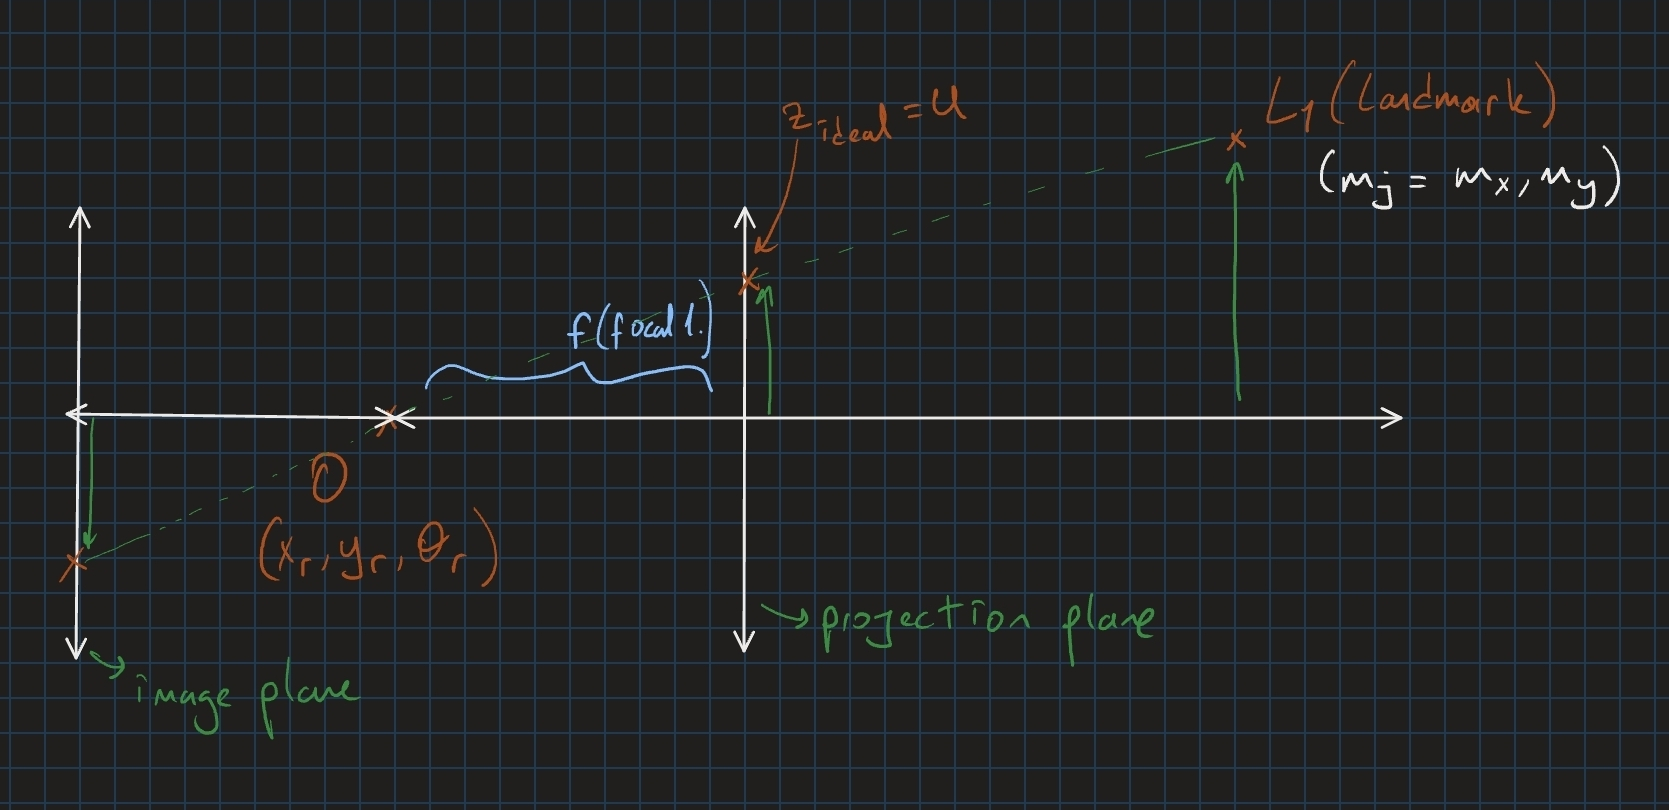

In [1]:
from IPython.display import Image, display
display(Image("visuals/pinhole_camera_ideal.jpg"))

Robot pose $x: (x_r, y_r, \theta_r)$ - This is the optical center O

Landmark $m_j: (m_x,m_y)$ - A point in the 2D world

Focal length $f$ - Distance from the optical center to the image plane and also projection plane which is same as virtual image plane

Image plane - The 1D sensor

Ideal measurement $z_{ideal}$ - The ideal pixel coordinate without noise

**Deterministic Camera Model:**

f (focal length)

$\sigma^2$ for the Gaussian noise model (not in the (a))

**Assumptions:**
* 1: The camera's optical center O is at the exact same location as the robot's pose x.
* 2: (Virtual Image Plane): We will use the "virtual image plane" or "projection plane" convention, as shown in the hand drawn diagram above. This places the 1D image plane in front of the optical center O at distance f.
    * Note: The "real "image plane is physically behind the pinhole, which would result in an inverted (upside-down) image ($z_ideal = +f* ...$). Both are mathematically equivalent for this problem but "in front" convention is simpler as it avoids negative signs.
* 3: The landmark $m_j$ is single 2D point (it has no rotation).

**Geometric Derivation of $z_{ideal} = h(h,m)$:**

We need to find the $z_{ideal}$ given the robot pose $x$ and landmark $m_j$.

We find the landmark's position relative to the robot, lets say for $L_{local_x}, L_{local_y}$ and robot is at (0,0) and facing towards X axis. 

Vector from robot to landmark in world frame:
$$
dx = m_x - x_r
$$
$$
dy = m_y - y_r
$$

Rotate the vector by $-\theta_r$ to get robot's coordinate system:

$$
L_{local_x} = dx * cos(\theta_r) + dy * sin(\theta_r)
$$
$$
L_{local_y} = -dx * sin(\theta_r) + dy * cos(\theta_r)
$$

Then we project onto Image Plane using Similar Triangles:

Big triangle : $L_{local_x}, L_{local_y}$
Small triangle : $f, z_{ideal}$
$$
\frac{z_{ideal}}{f} = \frac{L_{local_y}}{L_{local_x}}
$$
so the deterministic function is:
$$
h(x,m): z_{ideal}=f*\frac{L_{local_y}}{L_{local_x}}
$$

### A4.2:

the ideal measurement is $z_{ideal}$

the real measurement(zero centered) with noise is:

$$
z = z_{ideal} + \mathcal{N}(0, \sigma^2)
$$

This means the probability of getting a real measurement z given the robot pose x and map m is a Gaussian distribution centered at the ideal measurement $z_{ideal}$ with variance $\sigma^2$:

$$
p(z|x,m) = \mathcal{N}(z; z_{ideal}, \sigma^2) = \mathcal{N}(z; h(x,m), \sigma^2)
$$

### A4.3:

The closed form PDF algorithm:

1. function algorithm_camera_model(z,x,m): takes the inputs z (real measurement), x (robot pose), m (map)
2. Compute the ideal measurement: z_ideal = h(x,m)
3. Use the noise from (b) to compute the probability density: $p(z|x,m) = \mathcal{N}(z; z_{ideal}, \sigma^2)$
4. return p(z|x,m)

The sampling algorithm:

1. sample_robotpose_camera_model(z,m,$\lambda$):
    * $\lambda$ is f and $\sigma^2$ camera parameters.
2. Invert the deterministic model h(x,m) to express x in terms of z and m.
    * bearing to landmark requires solving $atan2(m_y-y_r, m_x-x_r)= \theta_r + \alpha_{local}$ we cannot solve it like this because of 3 unknowns (x_r,y_r,theta_r) and only 2 equations (z and bearing)

### A4.4:

 Derivation: algorithm_camera_model(z, x, m)

This is the algorithm that computes the probability $p(z|x,m)$.

Algorithm: algorithm_camera_model

Input:

**z:** The 1D pixel coordinate that was actually measured.

**x:** The robot's 3D pose (x_r, y_r, \theta_r).

**m:** The map, from which we get the landmark position m_j = (m_x, m_y).

**f, $\sigma^2$:** Camera parameters (focal length, noise variance).
Output:

prob: The probability $p(z | x, m)$.

---

Steps:

// Get robot pose and landmark position
$$
(x_r, y_r, \theta_r) = x
$$
$$
(m_x, m_y) = m_j
$$
// Step 1 from Q4(a): Convert to robot's local frame
$$
dx = m_x - x_r
$$
$$
dy = m_y - y_r
$$
$$
L_{local_x} = dx * \cos(\theta_r) + dy * \sin(\theta_r)
$$
$$
L_{local_y} = -dx * \sin(\theta_r) + dy * \cos(\theta_r)
$$
// Step 2 from Q4(a): Calculate the ideal, deterministic measurement
$$
z_{ideal} = f * \left(\frac{L_{local_y}}{L_{local_x}}\right)
$$

// Now use the noise model from Q4(b)
$$
error = z - z_{ideal}
$$
// Calculate the probability of this error in a $\mathcal{N}(0, \sigma^2)$ Gaussian
$$
exponent = -0.5 * (error**2) / (\sigma^2)
$$
$$
normalizer = 1.0 / \sqrt{2 \pi \sigma^2}
$$
$$
prob = normalizer * \exp(exponent)
$$
return prob

### A4.5:

This is the inverse problem. We are given a measurement z and want to guess (sample) a pose x that could have caused it.
* "Would this function be able to sample absolute robot poses?" No. A 1D measurement z only provides one piece of information (a bearing or angle). It cannot provide the 2D distance to the landmark. A robot 10m away and a robot 20m away along the same line would see the landmark at the same pixel z. 
* "If not, what can you sample?" You can sample the **bearing (orientation)**. More precisely, you can sample a pose x that is consistent with the measurement, but that pose will have an unconstrained range. The algorithm in the textbook (Table 6.5 pg 180) works because it has both range and bearing. We only have bearing here.

**Algorithm: sample_robotpose_camera_model(z,m,λ)**
Input:
* z: The 1D pixel coordinate that was measured.
* m: The map, from which we get the landmark position $m_j = (m_x, m_y)$.
* λ: Camera parameters (focal length f, noise variance σ^2).
Output:
* $x_{sample}$: A possible 3D pose $(x_r, y_r, \theta_r)$ that could have produced measurement z.

Steps:
//Invert the noise model: Sample a hyphothetical "ideal" measurement
1. $z_{ideal_{sample}}= z + np.random.normal(0, \sigma)$
//Invert the geometric model: Find the bearing angle (in robot's frame)
2. //From $z= f * \frac{L_{local_y}}{L_{local_x}}$ we get $ \frac{L_{local_y}}{L_{local_x}} = \frac{z}{f}$

// This ratio is the tangent of the angle to the landmark *in the robot's frame* $\alpha_{local}=atan(z_{ideal_{sample}} / f)$
3. //This is the hard part. We have 1 equation: 
// bearing_to_landmark = $robot_{angle}+local_{bearing} atan2(m_y - y_r, m_x - x_r)= \theta_r + \alpha_{local}$
Again this equation has 3 unknowns $(x_r, y_r, theta_r) $ We cannot solve it uniquely. 

Here is a simplified approach assuming random distance: 
```
d_sample = "a random distance" (e.g., np.random.uniform(1, 20) meters)

// We can now find the robot's (x_r, y_r) position.

// The robot is on a circle of radius d_sample around the landmark.

world_bearing_sample = np.random.uniform(0, 2*pi)

x_r = m_x - d_sample * cos(world_bearing_sample)

y_r = m_y - d_sample * sin(world_bearing_sample)

// Now we can find the robot's orientation \theta_r

\theta_r = world_bearing_sample - alpha_local

return (x_r, y_r, \theta_r)
```

### A4.6:

The Main Difficulty (from your lecturer): The problem is asymmetric and non-linear.

Forward Problem (d): p(z | x, m): Easy. Physics is causal.
3D Pose (x,y,\theta) -> 2D local (L_x, L_y) -> 1D ideal (z_ideal) -> 1D noisy (z)
A Gaussian \mathcal{N}(0, \sigma^2) is just added at the end.

Inverse Problem (e): p(x | z, m): Hard. We have to invert the process.
1D noisy (z) -> 1D ideal (z_ideal) -> ???

As your lecturer said, back-projecting the 1D Gaussian \mathcal{N}(z; ...) from the image plane into the 2D world does not create a Gaussian. It creates the "uncertainty cone" (belirsizlik bölgesi).

The shape of this belief p(x | z, m) in the 2D world is a "weird density" (garip bir density) that is not a Gaussian. This is the central difficulty. The sensor model is simple, but the belief it creates about the robot's pose is complex.